# Langchain setup

In [ ]:
!pip install openai==0.28.1 langchain==0.0.270 langchain-community

In [ ]:
#secret Key

import os
from google.colab import userdata

# Retrieve API keys from Colab's secure storage

openai_api_key = userdata.get("openai")

# Set them as environment variables

if openai_api_key:
    os.environ["OPENAI_API_KEY"] = openai_api_key

## Chains

Restaraunt Business Generator

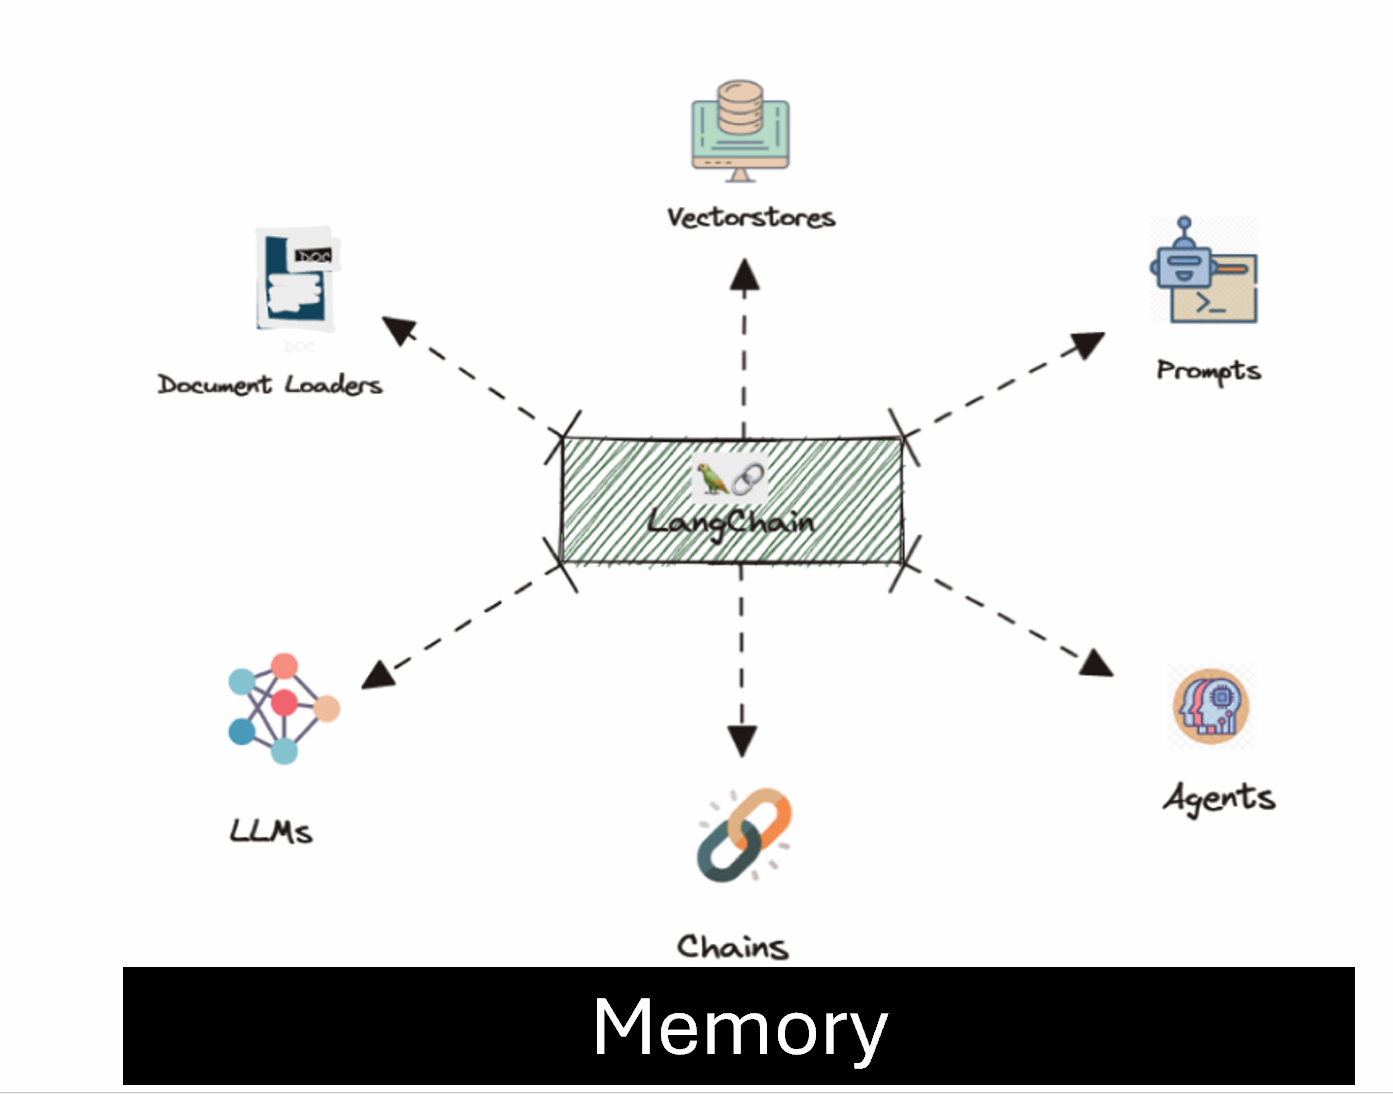

In [ ]:
from langchain.chains.llm import LLMChain
from langchain.prompts import PromptTemplate
from langchain.llms import OpenAI
from langchain.chains.sequential import SequentialChain
from langchain.chat_models import ChatOpenAI # Import ChatOpenAI

# Use ChatOpenAI with a chat-optimized model like gpt-3.5-turbo
llm = ChatOpenAI(temperature = 1, model_name="gpt-3.5-turbo")

prompt_template_name= PromptTemplate(
    input_variables = ['cuisine'],
    template = "i want to open a restaraunt for  {cuisine} food. Suggest a fancy name for this"
                                         )


name_chain=LLMChain(llm=llm,prompt=prompt_template_name,output_key="restaraunt_name")




# Re-initialize llm with ChatOpenAI for the second chain as well
llm = ChatOpenAI(temperature = 1, model_name="gpt-3.5-turbo")

prompt_template_items = PromptTemplate(input_variables=['restaraunt_name', 'cuisine'],
                                      template="Suggest me some menu items for {restaraunt_name} which is {cuisine} cuisine. Only mention items names ,break down according to category like drinks soup starters main course"
                                       )

food_items_chain=LLMChain(llm=llm,prompt=prompt_template_items,output_key="menu_items")




chain = SequentialChain(
    chains = [name_chain, food_items_chain],
    input_variables =['cuisine'],
    output_variables = ['restaraunt_name','menu_items']
)


In [ ]:
chain({"cuisine": "Chinese"})

{'cuisine': 'Chinese',
 'restaraunt_name': 'Imperial Dragon Cuisine',
 'menu_items': "Drinks: \n1. Jasmine green tea\n2. Lychee martini\n\nSoup:\n1. Hot and sour soup\n2. Wonton soup\n\nStarters:\n1. Spring rolls\n2. Steamed dumplings\n3. Scallion pancakes\n\nMain Course:\n1. General Tso's chicken\n2. Kung Pao shrimp\n3. Beef with broccoli\n4. Vegetable lo mein\n5. Mapo tofu"}

In [ ]:
chain({"cuisine": "French"})

{'cuisine': 'French',
 'restaraunt_name': '"Le Coq et L\'Escargot"',
 'menu_items': 'Drinks:\n1. Kir Royale\n2. French 75\n3. Chardonnay\n4. Cabernet Sauvignon\n\nSoup:\n1. French Onion Soup\n2. Vichyssoise (cold potato and leek soup)\n\nStarters:\n1. Escargot de Bourgogne\n2. Coquilles St. Jacques\n3. Foie Gras\n4. Salade Niçoise\n\nMain Course:\n1. Coq au Vin\n2. Bouillabaisse\n3. Beef Bourguignon\n4. Ratatouille'}

In [ ]:
pip install gradio

In [ ]:


import gradio as gr
from langchain.chains import LLMChain, SequentialChain
from langchain.prompts import PromptTemplate
from langchain.llms import OpenAI

# DDS Logo URL
DDS_LOGO_URL = "https://raw.githubusercontent.com/Decoding-Data-Science/airesidency/main/dds_logo.jpg"

# Define LLM chains as provided
llm = ChatOpenAI(temperature = 1, model_name="gpt-3.5-turbo")
prompt_template_name = PromptTemplate(
    input_variables=['cuisine'],
    template="i want to open a restaraunt for  {cuisine} food. Suggest a fancy name for this"
)
name_chain = LLMChain(llm=llm, prompt=prompt_template_name, output_key="restaraunt_name")

llm = ChatOpenAI(temperature = 1, model_name="gpt-3.5-turbo")
prompt_template_items = PromptTemplate(
    input_variables=['restaraunt_name', 'cuisine'],
    template="Suggest me some menu items for {restaraunt_name} which is {cuisine} cuisine. Only mention items names, break down according to category like drinks, soup, starters, main course"
)
food_items_chain = LLMChain(llm=llm, prompt=prompt_template_items, output_key="menu_items")

chain = SequentialChain(
    chains=[name_chain, food_items_chain],
    input_variables=['cuisine'],
    output_variables=['restaraunt_name', 'menu_items']
)

# Popular cuisines dropdown options
TOP_CUISINES = [
    "Italian", "Chinese", "Japanese", "Mexican", "Indian",
    "French", "Thai", "Mediterranean", "American", "Spanish"
]

# Function to run the chain and return outputs
def generate_restaurant(cuisine):
    outputs = chain({'cuisine': cuisine})
    return outputs['restaraunt_name'], outputs['menu_items']

# Build Gradio interface
with gr.Blocks(title="Restaurant Business Generator", theme="default") as demo:
    with gr.Row():
        with gr.Column(scale=1, min_width=200):
            gr.Image(DDS_LOGO_URL, label="Decoding Data Science", elem_id="dds-logo")
            gr.Markdown(
                "**Restaurant Business Generator**  \n"
                "Choose a cuisine type, or select from popular options, then generate a restaurant name and menu instantly."
            )
            cuisine_dropdown = gr.Dropdown(choices=TOP_CUISINES, label="Popular Cuisines", value=TOP_CUISINES[0])
            generate_btn = gr.Button("Generate")
        with gr.Column(scale=2):
            name_output = gr.Textbox(label="Suggested Restaurant Name", interactive=False)
            menu_output = gr.Textbox(label="Suggested Menu Items", lines=10, interactive=False)

    generate_btn.click(fn=generate_restaurant, inputs=cuisine_dropdown, outputs=[name_output, menu_output])

if __name__ == "__main__":
    demo.launch()


/tmp/ipykernel_6031/1392028756.py:42: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(title="Restaurant Business Generator", theme="default") as demo:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c42cef67d67563c03d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
from langchain.chains import LLMChain, SequentialChain
from langchain.prompts import PromptTemplate
from langchain.llms import OpenAI

# DDS Logo URL
DDS_LOGO_URL = "https://raw.githubusercontent.com/Decoding-Data-Science/airesidency/main/dds_logo.jpg"

# Define LLM chains as provided
llm = ChatOpenAI(temperature = 1, model_name="gpt-3.5-turbo")
prompt_template_name = PromptTemplate(
    input_variables=['cuisine'],
    template="i want to open a restaraunt for  {cuisine} food. Suggest a fancy name for this"
)
name_chain = LLMChain(llm=llm, prompt=prompt_template_name, output_key="restaraunt_name")

llm = ChatOpenAI(temperature = 1, model_name="gpt-3.5-turbo")
prompt_template_items = PromptTemplate(
    input_variables=['restaraunt_name', 'cuisine'],
    template="Suggest me some menu items for {restaraunt_name} which is {cuisine} cuisine. Only mention items names, break down according to category like drinks, soup, starters, main course"
)
food_items_chain = LLMChain(llm=llm, prompt=prompt_template_items, output_key="menu_items")

chain = SequentialChain(
    chains=[name_chain, food_items_chain],
    input_variables=['cuisine'],
    output_variables=['restaraunt_name', 'menu_items']
)

# Popular cuisines dropdown options
TOP_CUISINES = [
    "Italian", "Chinese", "Japanese", "Mexican", "Indian",
    "French", "Thai", "Mediterranean", "American", "Spanish"
]

# Function to run the chain and return outputs
def generate_restaurant(cuisine):
    outputs = chain({'cuisine': cuisine})
    return outputs['restaraunt_name'], outputs['menu_items']

In [ ]:
generate_restaurant("Indian")

('"Spice Palace"',
 'Sure! Here are some menu items for Spice Palace:\n\nDrinks:\n1. Mango Lassi\n2. Masala Chai\n3. Jaljeera\n\nSoup:\n1. Mulligatawny Soup\n2. Sambar Soup\n\nStarters:\n1. Vegetable Pakoras\n2. Chicken Tikka\n3. Samosa Chaat\n\nMain Course:\n1. Butter Chicken\n2. Rogan Josh\n3. Palak Paneer\n4. Chana Masala\n5. Biryani\n\nI hope you enjoy these delicious Indian cuisine options at Spice Palace!')

## Agents

In [ ]:
import os
from google.colab import userdata

SERPAPI_API_KEY = userdata.get("SERP_API")

# Set them as environment variables

if SERPAPI_API_KEY:
    os.environ["SERPAPI_API_KEY"] = SERPAPI_API_KEY

In [ ]:
pip install google-search-results

  Preparing metadata (setup.py) ... done
  Created wheel for google-search-results: filename=google_search_results-2.4.2-py3-none-any.whl size=32010 sha256=f54b1aab3c5a2d90d27e13f4a99cd669074575d07ad31b3b99abdd45a76cb8c9
  Stored in directory: /root/.cache/pip/wheels/0c/47/f5/89b7e770ab2996baf8c910e7353d6391e373075a0ac213519e
Successfully built google-search-results


#### serpapi and llm-math tool

In [ ]:
pip install wikipedia

  Preparing metadata (setup.py) ... done
  Created wheel for wikipedia: filename=wikipedia-1.4.0-py3-none-any.whl size=11678 sha256=40bd8089ffa0d9ed116d9c8eaff2febffe785ec7eec128a16977c4a6863b06fa
  Stored in directory: /root/.cache/pip/wheels/63/47/7c/a9688349aa74d228ce0a9023229c6c0ac52ca2a40fe87679b8
Successfully built wikipedia


In [ ]:
from langchain.agents import AgentType, initialize_agent, load_tools
from langchain.chat_models import ChatOpenAI # Import ChatOpenAI

# Initialize LLM with a supported chat model
llm = ChatOpenAI(temperature=0, model="gpt-3.5-turbo")

# The tools we'll give the Agent access to. Note that the 'llm-math' tool uses an LLM, so we need to pass that in.
tools = load_tools(["serpapi","wikipedia", "llm-math"], llm=llm)

# Finally, let's initialize an agent with the tools, the language model, and the type of agent we want to use.
agent = initialize_agent(tools, llm, agent=AgentType.ZERO_SHOT_REACT_DESCRIPTION, verbose=True)

# Let's test it out!
agent.run("What was the GDP of US in 2024? Add 5 trillion to this number.")



> Entering new AgentExecutor chain...
I need to find out the GDP of the US in 2024 first before adding 5 trillion to it.
Action: Search
Action Input: "US GDP 2024"
Observation: Real GDP increased 2.8 percent in 2024 (from the 2023 annual level to the 2024 annual level), the same as previously estimated. The increase in ...
Thought:I need to find the actual GDP number to add 5 trillion to it.
Action: Search
Action Input: "US GDP 2024 in trillion"
Observation: In 2025, the United States had the largest economy in the world, with a gross domestic product of over 30.6 trillion U.S. dollars. China was the ...
Thought:Now I can add 5 trillion to the US GDP in 2024.
Action: Calculator
Action Input: 30.6 + 5
Observation: Answer: 35.6
Thought:I now know the final answer
Final Answer: The GDP of the US in 2024 was 30.6 trillion, and adding 5 trillion to this gives a total of 35.6 trillion.

> Finished chain.


'The GDP of the US in 2024 was 30.6 trillion, and adding 5 trillion to this gives a total of 35.6 trillion.'

#### Wikipedia and llm-math tool

In [ ]:
pip install wikipedia

In [ ]:
# install this package: pip install wikipedia

# The tools we'll give the Agent access to. Note that the 'llm-math' tool uses an LLM, so we need to pass that in.
tools = load_tools(["wikipedia", "llm-math"], llm=llm)

# Finally, let's initialize an agent with the tools, the language model, and the type of agent we want to use.
agent = initialize_agent(
    tools,
    llm,
    agent=AgentType.ZERO_SHOT_REACT_DESCRIPTION,
    verbose=True
)

# Let's test it out!
#agent.run("When was Elon musk born? What is his current age in days")
agent.run("How many balloons can we fit in a380?")





> Entering new AgentExecutor chain...
I should use the calculator to calculate the volume of the A380 and then estimate the volume of a balloon to see how many can fit.
Action: Calculator
Action Input: Calculate the volume of an Airbus A380
Observation: Answer: 284246.004
Thought:Now I need to estimate the volume of a balloon.
Action: Calculator
Action Input: Calculate the volume of a balloon
Observation: Answer: 523.3333333333334
Thought:Now I can divide the volume of the A380 by the volume of a balloon to find out how many balloons can fit.
Action: Calculator
Action Input: 284246.004 / 523.3333333333334
Observation: Answer: 543.1452305732483
Thought:I now know the final answer
Final Answer: Approximately 543 balloons can fit in an Airbus A380.

> Finished chain.


'Approximately 543 balloons can fit in an Airbus A380.'